In [1]:
0

0

In [1]:
0

0

In [2]:
from PIL import Image

In [4]:
img_path = r"C:\Users\shami\Tech\projects\quick-draw-proto\data\testing\axe\_72.png"
img = Image.open(img_path)

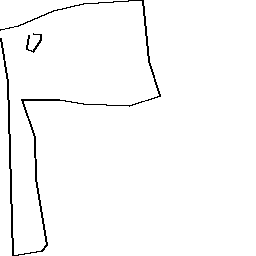

In [5]:
img

In [6]:
import numpy as np

In [7]:
img_arr = np.array(img)

In [8]:
img_arr

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], shape=(256, 256), dtype=uint8)

In [9]:
img_arr.shape

(256, 256)

In [17]:
# Load grayscale image
img = Image.open(img_path).convert('L')  # 'L' mode for grayscale

# Convert to 3-channel (RGB) image
img_rgb = np.array(img)  # Convert to numpy array (shape: 256x256)
img_rgb = np.repeat(img_rgb[..., np.newaxis], 3, axis=-1)  # Repeat grayscale values across 3 channels

# Convert back to Image (optional)
img_rgb = Image.fromarray(img_rgb)

# Resize to the input size expected by your model
img_rgb = img_rgb.resize((192, 192))

# Convert to numpy array and normalize
img_array = np.array(img_rgb).transpose(2, 0, 1).astype(np.float32) / 255.0  # Normalize to [0, 1]

# Add batch dimension (for model input)
img_array = np.expand_dims(img_array, axis=0)

img_array.shape

(1, 3, 192, 192)

In [19]:
print(img_array)

[[[[1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]
   ...
   [1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]]

  [[1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]
   ...
   [1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]]

  [[1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]
   ...
   [1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]
   [1. 1. 1. ... 1. 1. 1.]]]]


In [21]:
import onnxruntime as ort


session = ort.InferenceSession("model.onnx")

# Step 3: Get input name dynamically (in case it's not "input")
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name
pred = session.run([output_name], {input_name: img_array})

# Step 5: Interpret
predictions = pred[0]  # shape: (1, num_classes)
predicted_class = np.argmax(predictions)

print("Prediction:", predicted_class)


Prediction: 14


In [22]:
import json

with open("vocab.json", "r") as f:
    vocab = json.load(f)

outputs = session.run([output_name], {input_name: img_array})[0]
probs = np.exp(outputs) / np.sum(np.exp(outputs), axis=1)  # Softmax
pred_idx = np.argmax(probs, axis=1)[0]
pred = vocab[pred_idx]  # Map index to class name

# Print results
print(f"Prediction: {pred}")


Prediction: axe


In [44]:
output_name

'output'

In [45]:
data = {
    "input": img_array.tolist()  # Convert to nested lists
}

# Optional: Save JSON to file if testing with Postman
with open("payload.json", "w") as f:
    json.dump(data, f)

In [48]:
import base64
from io import BytesIO
img = Image.fromarray((img_array[0].transpose(1, 2, 0) * 255).astype(np.uint8))

# Convert to base64
buffered = BytesIO()
img.save(buffered, format="PNG")
img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")

# Send this JSON via Postman
payload = {
    "image": img_str
}

In [49]:
payload

{'image': 'iVBORw0KGgoAAAANSUhEUgAAAMAAAADACAIAAADdvvtQAAAOx0lEQVR4nO2dbUxTZxuAnx5Oe1o+KmjimGNFEDchWkVYXlCRzgkikv3BbCZzs0BrEesvEliCIWNuP2Z0jsiMfIgM+WEWF7esMU42LRtOjAiIG8NQcDBkhWR8Qzk9pX3zehamKLyj5xxoz3Nfv4T2nD7A5fNxP/dzH4nL5UK44nA4rl+/PjU1Ndcb7Ha7VquNjY2d6w2///671WodGhpSKBQISyQiFujmzZsmk8npdM71hocPH3Z2du7cuXOem0RGRmq12rlePXbsWGFh4eTkJLYCkcjbYBhmfHwcIZSbm9vb2yuRSOZ6Z0dHh8FgWL9+/VxveP3116Ojo1944QW3G+NwOBDeeIdA/f39zc3N09PTCKG8vLwXX3zRx8eHpumLFy9SFDXXVSRJBgQECNowmqYRQth2P54+hNXX17NjUG1tbURERFhYGELI39+/sLAQeQZms/mdd94pKCjIyclBWOJZAo2MjDidzgsXLnzzzTckSc6MQRRFaTQakvTE/jIuLm50dLStrQ1hyRL/SRwOh9lsZgeCmpoai8WyfPlym8320UcfbdiwYRHGIO5MT0/7+fkhXFkagaxW6+nTpxmGefjwocViSUpKQgiFh4efOnUqODh4SZoEeIFAk5OTNE3n5ua2trauXbt2//79O3bs4LgOArAQqL+///bt25mZmTExMTRNX7lyZeXKlYvz0YDXC/Thhx9evnw5IiLixIkT8wTlvBSXyzVPLEr0CCUQwzANDQ0FBQUymezPP/8sLi722GUUR+Ryuc1mYxhGKpUiDHHxDcMwtbW1UVFRiYmJxcXFg4ODdrvdJV6GhoYIgjh27JgLS0je436dnZ0Wi+Xtt9/2nHCfoMjlcqfTabfbEZbwI9DAwMBbb73V09NjMBiysrKwWli5HkdisZ0GcRLo119/7e7uvnDhQkdHh1qt/vbbb